## Programming project: probability of death

In this project, you have to predict the probability of death of a patient that is entering an ICU (Intensive Care Unit).

The dataset comes from MIMIC project (https://mimic.physionet.org/). MIMIC-III (Medical Information Mart for Intensive Care III) is a large, freely-available database comprising deidentified health-related data associated with over forty thousand patients who stayed in critical care units of the Beth Israel Deaconess Medical Center between 2001 and 2012.

Each row of *mimic_train.csv* correponds to one ICU stay (*hadm_id*+*icustay_id*) of one patient (*subject_id*). Column HOSPITAL_EXPIRE_FLAG is the indicator of death (=1) as a result of the current hospital stay; this is the outcome to predict in our modelling exercise.
The remaining columns correspond to vitals of each patient (when entering the ICU), plus some general characteristics (age, gender, etc.), and their explanation can be found at *mimic_patient_metadata.csv*.

Please don't use any feature that you infer you don't know the first day of a patient in an ICU.

Note that the main cause/disease of patient condition is embedded as a code at *ICD9_diagnosis* column. The meaning of this code can be found at *MIMIC_metadata_diagnose.csv*. **But** this is only the main one; a patient can have co-occurrent diseases (comorbidities). These secondary codes can be found at *extra_data/MIMIC_diagnoses.csv*.

As performance metric, you can use *AUC* for the binary classification case, but feel free to report as well any other metric if you can justify that is particularly suitable for this case.

Main tasks are:
+ Using *mimic_train.csv* file build a predictive model for *HOSPITAL_EXPIRE_FLAG* .
+ For this analysis there is an extra test dataset, *mimic_test_death.csv*. Apply your final model to this extra dataset and generate predictions following the same format as *mimic_kaggle_death_sample_submission.csv*. Once ready, you can submit to our Kaggle competition and iterate to improve the accuracy.

As a *bonus*, try different algorithms for neighbor search and for distance, and justify final selection. Try also different weights to cope with class imbalance and also to balance neighbor proximity. Try to assess somehow confidence interval of predictions.

You can follow those **steps** in your first implementation:
1. *Explore* and understand the dataset.
2. Manage missing data.
2. Manage categorial features. E.g. create *dummy variables* for relevant categorical features, or build an ad hoc distance function.
3. Build a prediction model. Try to improve it using methods to tackle class imbalance.
5. Assess expected accuracy  of previous models using *cross-validation*.
6. Test the performance on the test file and report accuracy, following same preparation steps (missing data, dummies, etc). Remember that you should be able to yield a prediction for all the rows of the test dataset.

Feel free to reduce the training dataset if you experience computational constraints.

## Project Summary
- Dataset includes ICU admissions with vitals/labs plus a separate table of all ICD-9 comorbidities.
- KNN (the baseline requirement) performs poorly; grid search shows it degrades as complexity increases.
- Linear models and Random Forests improve results; XGBoost performs best overall.
- ICD-9 and DIAGNOSIS are comorbidity and main diagnosis features with very high cardinality.
  - These features are encoded with a leakage-safe target-encoding strategy applied within CV folds.
- XGBoost with these engineered features achieves the highest Kaggle score.
- Feature importance and SHAP both confirm the value of the ICD-derived severity scores.
- *Demographics provide little signal*
    - missing values often indicate emergency/critical cases rather than real demographic effects.
- For deployment, demographic features will be handled ethically (missing = high acuity; known = irrelevant).
- Final model is designed for triage-style clinical decision support, with an API implementation coming soon.

# 0. Import libraries, initiate workspace and basic preprocessing


In [9]:
# Basic libraries
import pandas as pd
import numpy as np
from collections import Counter
# Sklearn
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, precision_score, fbeta_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler, FunctionTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import TargetEncoder
from category_encoders.target_encoder import TargetEncoder
from sklearn.metrics import make_scorer, fbeta_score
f2_scorer = make_scorer(fbeta_score, beta=2)
import xgboost as xgb
# Helper functions
import importlib
# import utils.helper_functions as hf
# importlib.reload(hf)
from utils.helper_functions import plot_confusion_matrix, get_auc, log_transform, grid_search, predict_test, oof_icd9_encoder

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
# Math
import math

Import train and test dataframes

In [10]:
train = pd.read_csv("../data/mimic_train.csv")
test = pd.read_csv("../data/mimic_test_death.csv")
comorbidity = pd.read_csv("../data/extra_data/MIMIC_diagnoses.csv")

Function for preprocessing data according to instructions
* Age feature is top censored for age > 89. Hence, I encode all such observations as 90
* Generate AGE_AT_ADMIT feature as the difference between ADMITTIME and DOB
* Drop features from drop_list as per instructions

In [50]:
# Preprocess data according to instructions:
drop_list = [ 'DOD', 'DISCHTIME', 'DEATHTIME', 'LOS', 'ADMITTIME', 'DOB']
def preproc(data):
    # Get date_of_birth and quarter of day of admission
    data['AGE_AT_ADMIT'] = pd.to_datetime(data['ADMITTIME']).dt.year - pd.to_datetime(data['DOB']).dt.year
    # Note that individuals older than 89 are encoded as 300, so I just enter 90 in these observations
    data['AGE_AT_ADMIT'] = data['AGE_AT_ADMIT'].apply(lambda x: 90 if x > 89 else x)
    data['QUART_DAY'] = np.ceil(pd.to_datetime(data['ADMITTIME']).dt.hour/6).astype("category")

    # Drop variables as per instructions
    for item in drop_list:
        if item in data.columns:
            data = data.drop(item, axis = 1)
        else:
            pass
    return data

Preprocess train and test sets:

In [51]:
train = preproc(train)
test = preproc(test)
# Check shapes of dfs:
print(f"Shape of training dataset: {train.shape} \n Shape of test dataset: {test.shape}")

Shape of training dataset: (20885, 40) 
 Shape of test dataset: (5221, 39)


# 1. EDA

Missing Data
- Missing observations are consistent across train and test datasets.
- If a variable has missing observations in train, it aslo has similar proportion of missing in test.


In [6]:
percent_missing_train = train.isnull().sum() * 100 / len(train)
percent_missing_test = test.isnull().sum() * 100 / len(test)
missing_value_df = pd.DataFrame({
                                 'data_type':train.dtypes,
                                 'percent_missing_train': percent_missing_train,
                                      'percent_missing_test':percent_missing_test})
missing_value_df

,data_type,percent_missing_train,percent_missing_test
ADMISSION_TYPE,object,0.000000,0.000000
AGE_AT_ADMIT,int64,0.000000,0.000000
DIAGNOSIS,object,0.000000,0.000000
DiasBP_Max,float64,10.576969,10.572687
DiasBP_Mean,float64,10.576969,10.572687
DiasBP_Min,float64,10.576969,10.572687
Diff,float64,0.000000,0.000000
ETHNICITY,object,0.000000,0.000000
FIRST_CAREUNIT,object,0.000000,0.000000
GENDER,object,0.000000,0.000000


Class Balance
- Data is not severely imbalanced

In [6]:
print(Counter(train.HOSPITAL_EXPIRE_FLAG))
print(f"Class-balance in train data = {len(train[train.HOSPITAL_EXPIRE_FLAG == 1]) *100 / len(train)} %")

Counter({0: 18540, 1: 2345})
Class-balance in train data = 11.228154177639453 %


## Plot features
- ICD9_diagnosis and Diagnosis have high cardinality.
- Most of the features are health markers.
- Are "nicely" distributed, spikes are due to binning differences.


In [52]:
numerical = train.select_dtypes(include=['int64', 'float64']).columns.to_list()
# Remove target feature and ID variables
remove_from_numerical = ['HOSPITAL_EXPIRE_FLAG', 'subject_id', 'hadm_id', 'icustay_id']
numerical = [feat for feat in numerical if feat not in remove_from_numerical]
categorical = train.select_dtypes(include=['object', 'category']).columns.to_list()

Numerical features

In [ ]:
n_cols = 4
n_feats = len(numerical)
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

axes = axes.flatten()

for i, feat in enumerate(numerical):
    sns.histplot(train[feat], ax=axes[i], kde=True)
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

Categorical features

In [ ]:
n_cols = 4
n_feats = len(categorical)
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

axes = axes.flatten()

for i, feat in enumerate(categorical):
    sns.histplot(train[feat], ax=axes[i], kde=True)
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

Violin plot for continuous features

In [ ]:
n_cols = 4
n_feats = len(numerical)
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

axes = axes.flatten()

for i, feat in enumerate(numerical):
    sns.violinplot(y = train[feat],
                   x = train['HOSPITAL_EXPIRE_FLAG'],
                   ax = axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

Plot categorical features with target

In [ ]:
n_cols = 4
n_feats = len(categorical)
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

axes = axes.flatten()

high_cardinality = ['ICD9_diagnosis', 'DIAGNOSIS']
categorical_plot = [feat for feat in categorical if feat not in high_cardinality]

for i, feat in enumerate(categorical_plot):
    sns.barplot(x = train[feat],
                y = train['HOSPITAL_EXPIRE_FLAG'],
                data = train,
                ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

Create target and feature dfs

In [53]:
# Create target feature
y = train['HOSPITAL_EXPIRE_FLAG']
# Drop ID variables and ICD9 and Diff since we have age
X_simple = train.drop(['HOSPITAL_EXPIRE_FLAG', 'subject_id', 'hadm_id', 'icustay_id', 'Diff', 'ICD9_diagnosis', 'DIAGNOSIS'], axis = 1)
print(f"Shape of training dataset: {X_simple.shape} \n Shape of test dataset: {y.shape}")

Shape of training dataset: (20885, 33) 
 Shape of test dataset: (20885,)


In [54]:
categorical_simple = X_simple.select_dtypes(include = ['object', 'category']).columns
# isolate ICD9_diagnosis from categorical features
numerical_simple = X_simple.select_dtypes(include = [np.number]).columns
# Check that I have captured all features:
assert set(categorical_simple) | set(numerical_simple) == set(X_simple.columns), "Features not captured"

# 2. TRAINING A KNN CLASSIFIER:
* Additional mortality features generated from the comorbiidty datasets will be encoded using the target feature.
* This is highly likely to overfit . I first run a simple model without these additional features to gauge the general performance of a model.
* Start with k = sqrt(len(train)) as an initial value.

## 2.1 Simple KNN Model - baseline
- In-sample accuracy: 0.89064
- In-sample f2 score: 0.037
- ROC_AUC: 0.8012

In [ ]:
# Initial value for K
initial_n = round(np.sqrt(len(train)))
print(f"Starting value for KNN Classifier: {initial_n}")

# Create pipeline
numeric_transformer = Pipeline(
             steps = [("imputer", SimpleImputer(strategy = "mean")),
                     ("scaler", StandardScaler())])
categorical_transformer = Pipeline(
             steps = [ ("imputer", SimpleImputer(strategy = "most_frequent")),
                        ( "ohe", OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
# preprocessor pipeline combining both:
preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numerical_simple),
        ("cat", categorical_transformer, categorical_simple)
])
# Define the pipeline for preprocessing and the classifier.
clf_simple = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', KNeighborsClassifier(n_neighbors = initial_n,
                                                          n_jobs = -1))])
# Check structure of pipeline:
clf_simple

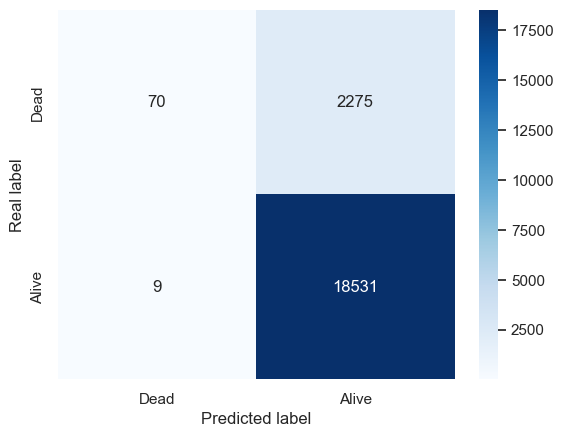

Accuracy :  0.8906392147474264
ROC_AUC :  0.8012009646635062
AUC:  0.8012009646635062


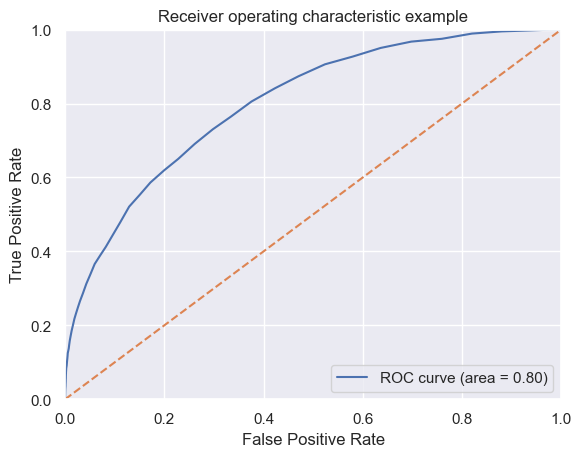

In [185]:
# Fit the model
clf_simple.fit(X_simple, y)
# Get in-sample point and probability fitted values
y_hat_in_simple = clf_simple.predict(X_simple)
y_hat_in_proba_simple = clf_simple.predict_proba(X_simple)
# Confusion Matrix
class_labels = ["Dead","Alive"]
cm =  confusion_matrix(y_pred=y_hat_in_simple, y_true=y, labels=[1,0])
# Plotting confusion matrix
plot_confusion_matrix(cm, class_labels)
# ROC_AUC
print("Accuracy : ", round(accuracy_score(y,y_hat_in_simple),5))
print("ROC_AUC : ", round(roc_auc_score(y, y_hat_in_proba_simple[:,1]),5))
class_labels = ["0","1"]
get_auc(y, y_hat_in_proba_simple, class_labels, plot=True)

## 2.1.2 Grid Search With Simple Model
- Model is highly overfitted - accuracy = 1 with low test set performance.
- In grid search, the optimal value of k consistently collapses to k = 1, with weights='distance' being selected.
- The KNN model is assigning highest weight to an observations self-distance and is not suitable for this dataset.
- Kaggle Score: 0.79269

In [194]:
param_grid = {#'classifier__n_neighbors': [115, 125, 135, 145, 155],
              # 'classifier__n_neighbors': [115,105,95],
              #   'classifier__n_neighbors': [75, 85, 95],
                'classifier__n_neighbors': [75, 50, 25],
              'classifier__weights': ['uniform', 'distance'],
              'classifier__p': [1, 2] #All models choose p = 2, so I abandon this parameter search
              }
# Execute grid search
scores = grid_search(classifier_pipline = clf_simple,
            features = X_simple,
            target = y,
            parameter_grid = param_grid,
            scoring = f2_scorer)

# Create test submissions
predict_test(X_train = X_simple,
             y =  y,
             X_test = test,
             model_scores = scores,
             model_name = 'random_forest')
print(f'In-sample accuracy: {scores["accuracy"]}\nIn-sample ROC_AUC: {scores["roc_auc"]}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5; 1/12] START classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform
[CV 1/5; 1/12] END classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform;, score=0.029 total time=   3.7s
[CV 2/5; 1/12] START classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform
[CV 2/5; 1/12] END classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform;, score=0.013 total time=   3.9s
[CV 3/5; 1/12] START classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform
[CV 3/5; 1/12] END classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform;, score=0.016 total time=   3.7s
[CV 4/5; 1/12] START classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform
[CV 4/5; 1/12] END classifier__n_neighbors=75, classifier__p=1, classifier__weights=uniform;, score=0.021 total time=   3.1s
[CV 5/5; 1/12] START classifier__n_neighbors=75, classifier__p=

## 2.2 Logistic Regression
- Kaggle Score: 0.82841

Fitting 3 folds for each of 400 candidates, totalling 1200 fits
[CV 1/3; 1/400] START classifier__C=0.0001, classifier__penalty=l1, classifier__solver=lbfgs
[CV 1/3; 1/400] END classifier__C=0.0001, classifier__penalty=l1, classifier__solver=lbfgs;, score=nan total time=   0.2s
[CV 2/3; 1/400] START classifier__C=0.0001, classifier__penalty=l1, classifier__solver=lbfgs
[CV 2/3; 1/400] END classifier__C=0.0001, classifier__penalty=l1, classifier__solver=lbfgs;, score=nan total time=   0.1s
[CV 3/3; 1/400] START classifier__C=0.0001, classifier__penalty=l1, classifier__solver=lbfgs
[CV 3/3; 1/400] END classifier__C=0.0001, classifier__penalty=l1, classifier__solver=lbfgs;, score=nan total time=   0.1s
[CV 1/3; 2/400] START classifier__C=0.0001, classifier__penalty=l1, classifier__solver=newton-cg
[CV 1/3; 2/400] END classifier__C=0.0001, classifier__penalty=l1, classifier__solver=newton-cg;, score=nan total time=   0.1s
[CV 2/3; 2/400] START classifier__C=0.0001, classifier__penalty=l1, 

/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3; 90/400] END classifier__C=0.004832930238571752, classifier__penalty=l2, classifier__solver=saga;, score=0.133 total time=   1.6s
[CV 2/3; 90/400] START classifier__C=0.004832930238571752, classifier__penalty=l2, classifier__solver=saga


/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3; 90/400] END classifier__C=0.004832930238571752, classifier__penalty=l2, classifier__solver=saga;, score=0.124 total time=   1.7s
[CV 3/3; 90/400] START classifier__C=0.004832930238571752, classifier__penalty=l2, classifier__solver=saga


...

/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3; 390/400] END classifier__C=10000.0, classifier__penalty=l2, classifier__solver=saga;, score=0.194 total time=   2.0s
[CV 3/3; 390/400] START classifier__C=10000.0, classifier__penalty=l2, classifier__solver=saga


/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 3/3; 390/400] END classifier__C=10000.0, classifier__penalty=l2, classifier__solver=saga;, score=0.188 total time=   2.0s
[CV 1/3; 391/400] START classifier__C=10000.0, classifier__penalty=elasticnet, classifier__solver=lbfgs
[CV 1/3; 391/400] END classifier__C=10000.0, classifier__penalty=elasticnet, classifier__solver=lbfgs;, score=nan total time=   0.1s
[CV 2/3; 391/400] START classifier__C=10000.0, classifier__penalty=elasticnet, classifier__solver=lbfgs
[CV 2/3; 391/400] END classifier__C=10000.0, classifier__penalty=elasticnet, classifier__solver=lbfgs;, score=nan total time=   0.1s
[CV 3/3; 391/400] START classifier__C=10000.0, classifier__penalty=elasticnet, classifier__solver=lbfgs
[CV 3/3; 391/400] END classifier__C=10000.0, classifier__penalty=elasticnet, classifier__solver=lbfgs;, score=nan total time=   0.1s
[CV 1/3; 392/400] START classifier__C=10000.0, classifier__penalty=elasticnet, classifier__solver=newton-cg
[CV 1/3; 392/400] END classifier__C=10000.0, classifier

/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
780 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator

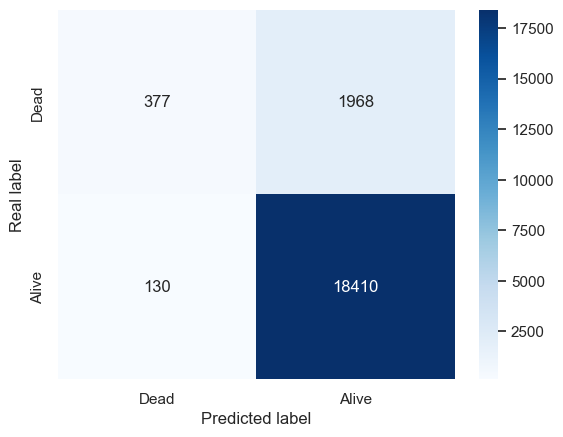

/Users/gnlm/Desktop/ds_projects/Probability-of-Death/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
from sklearn.linear_model import LogisticRegression

logistic_simple = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', LogisticRegression())])
param_grid = [
    {'classifier__penalty':['l1','l2','elasticnet','none'],
    'classifier__C' : np.logspace(-4,4,20),
    'classifier__solver': ['lbfgs','newton-cg','liblinear','sag','saga']}]

# Execute grid search
scores = grid_search(classifier_pipline = logistic_simple,
            features = X_simple,
            target = y,
            parameter_grid = param_grid,
            scoring = f2_scorer)

# Create test submissions
predict_test(X_train = X_simple,
             y =  y,
             X_test = test,
             model_scores = scores,
             model_name = 'logistic')
print(f'In-sample accuracy: {scores["accuracy"]}\nIn-sample ROC_AUC: {scores["roc_auc"]}')

## 2.3 Random Forest
- Kaggle Score: 0.84789

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state = 42))
])
param_grid = [
    {'classifier__n_estimators': [100,150, 200], #[100,200, 300, 400, 500]
     'classifier__max_depth' : [10, 20],
     'classifier__min_samples_split': [20, 30],
     'classifier__min_samples_leaf': [5, 10],
     'classifier__max_features': ['sqrt', 'log2'],
     'classifier__bootstrap': [True, False]}
]

# Execute grid search
scores = grid_search(classifier_pipline = rf_classifier,
            features = X_simple,
            target = y,
            parameter_grid = param_grid,
            scoring = f2_scorer)

# Create test submissions
predict_test(X_train = X_simple,
             y =  y,
             X_test = test,
             model_scores = scores,
             model_name = 'random_forest')
# In-sample performance
print(f'In-sample accuracy: {scores['accuracy']}\nIn-sample ROC_AUC: {scores["roc_auc"]}')

## 2.4 XGBoost
- Kaggle Score: 0.85303
- In-sample accuracy: 0.92794
- In-sample ROC_AUC: 0.92766

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV 1/3; 1/24] START classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8
[CV 1/3; 1/24] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8;, score=0.168 total time=   0.6s
[CV 2/3; 1/24] START classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8
[CV 2/3; 1/24] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8;, score=0.188 total time=   0.5s
[CV 3/3; 1/24] START classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8
[CV 3/3; 1/24] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8;, score=0.215 total time=   0.6s
[CV 1/3; 2/24] START classifier__learning_

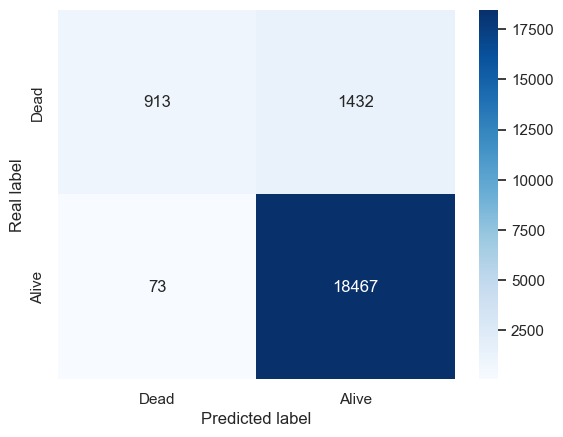

In-sample accuracy: 0.92794
In-sample ROC_AUC: 0.92766


In [228]:
xgb_classifier = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier())
])

param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [3, 6],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

# Execute grid search
scores = grid_search(classifier_pipline = xgb_classifier,
            features = X_simple,
            target = y,
            parameter_grid = param_grid,
            scoring = f2_scorer)

# Create test submissions
predict_test(X_train = X_simple,
             y =  y,
             X_test = test,
             model_scores = scores,
             model_name = 'XGB')
# In-sample performance
print(f'In-sample accuracy: {scores['accuracy']}\nIn-sample ROC_AUC: {scores["roc_auc"]}')

# 3 Feature Engineering -  Use Comorbidities feature set
## Final model -  XGB with comorbidities
Including the comorbidities and diagnosis data highly improves the model.
- In-sample accuracy: 0.98003
- In-sample ROC_AUC: 0.99565
- Kaggle Score: 0.93201

## 3.1 Feature Engineering - Target encode high cardinality features.

Incorporate comorbidities into the data set

ICD9 diagnosis and diagnosis features contain valuable information regarding the patient. However, cardinality of both features is extremely high. Dummifying the features would blow up the feature space and increase computation time drastically. Hence, I target encode them using the target feature to creat a 'mortality proxy' for each ICD9 code by combining the comorbidity data with the HOSPITAL_EXPIRE_FLAG. Furthermore, I add the mean and max probability of dying associated with the comorbidities for each patient.
- First, the first 3 characters of ICD9 codes relate to the broad category of the disease. Hence, I use it to reduce dimensionlaity.
- Second, I create 3 proxies for mortality.
- - First is the mean mortality rate for each ICD9 disease from the whole training set: mortality_proxy.
- - Second, is the mean mortality of the ICD9_diagnoses for each patient: mean_mortality.
- - Last is the maximum mortality for each patient: max_mortality

In [55]:
for df in [train, test]:
    df['ICD9_diagnosis'] = df['ICD9_diagnosis'].str[:3]
    df['ICD9_diagnosis'] = df['ICD9_diagnosis'].astype("str")
comorbidity['ICD9_CODE'] = comorbidity['ICD9_CODE'].str[:3]
# Convert comorbiidty df columns to lowercase
comorbidity = comorbidity.rename(columns=str.lower)
# Drop na's as there is no way to infer these data
comorbidity = comorbidity.dropna()

## 3.2 Final Model

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV 1/3; 1/24] START classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8
[CV 1/3; 1/24] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8;, score=0.407 total time=   0.6s
[CV 2/3; 1/24] START classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8
[CV 2/3; 1/24] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8;, score=0.430 total time=   0.4s
[CV 3/3; 1/24] START classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8
[CV 3/3; 1/24] END classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8;, score=0.391 total time=   0.4s
[CV 1/3; 2/24] START classifier__learning_

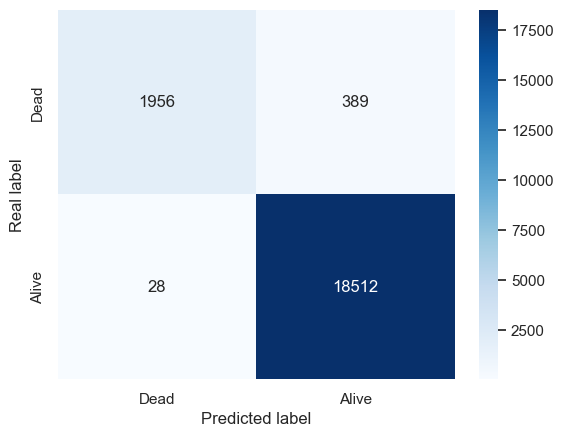

In-sample accuracy: 0.98003
In-sample ROC_AUC: 0.99565


In [56]:
train, test, comorbidity_mapping = oof_icd9_encoder(train, test, comorbidity)

numerical_cols = numerical_simple.to_list() + ['max_mortality', 'mean_mortality', 'count_comorbidities', 'DIAGNOSIS']

# Also encode the "DIAGNOSIS" feature
diagnosis_encoder = TargetEncoder(
    cols=['DIAGNOSIS'],
    smoothing=0.25,          # reduces overfitting
    handle_missing='value',
    handle_unknown='value'
)

numeric_transformer = Pipeline(
             steps = [("imputer", SimpleImputer(strategy = "mean")),
                     ("scaler", StandardScaler())])
categorical_transformer = Pipeline(
             steps = [ ("imputer", SimpleImputer(strategy = "most_frequent")),
                        ( "ohe", OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
# preprocessor pipeline combining both:
preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_simple)],
remainder = 'drop')

pipeline_cols = numerical_cols + categorical_simple.to_list()
# Define the pipeline for preprocessing and the classifier.
xgb_classifier = Pipeline(steps=[
    ("diagnosis_target_encoder", diagnosis_encoder),
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier())])

param_grid = {
    'classifier__n_estimators': [100, 200, 500],#
    'classifier__max_depth': [3, 6], #, 6
    'classifier__learning_rate': [0.05, 0.1], #, 0.1
    'classifier__subsample': [0.8, 1.0]#, 1.0
}
# Execute grid search
scores = grid_search(classifier_pipline = xgb_classifier,
            features = train[pipeline_cols],
            target = y,
            parameter_grid = param_grid,
            scoring = f2_scorer)

# Create test submissions
predict_test(X_train = train[pipeline_cols],
             y =  y,
             X_test = test,
             model_scores = scores,
             model_name = 'XGB_GS')
# In-sample performance
print(f'In-sample accuracy: {scores["accuracy"]}\nIn-sample ROC_AUC: {scores["roc_auc"]}')

In [58]:
scores['best_params']

{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 6,
 'classifier__n_estimators': 200,
 'classifier__subsample': 0.8}

# 4.  Feature Importance and SHAP
- Feature importance and SHAP reveals that the model learns clinically meaningful signals: comorbidity-derived mortality risk, age, diagnosis severity, and extreme vital signs are the strongest predictors.
- Demographic fields contribute minimally, and when present, it is when the feature is missing - most likely picking up acute/emergency cases where the demographics can't be established.

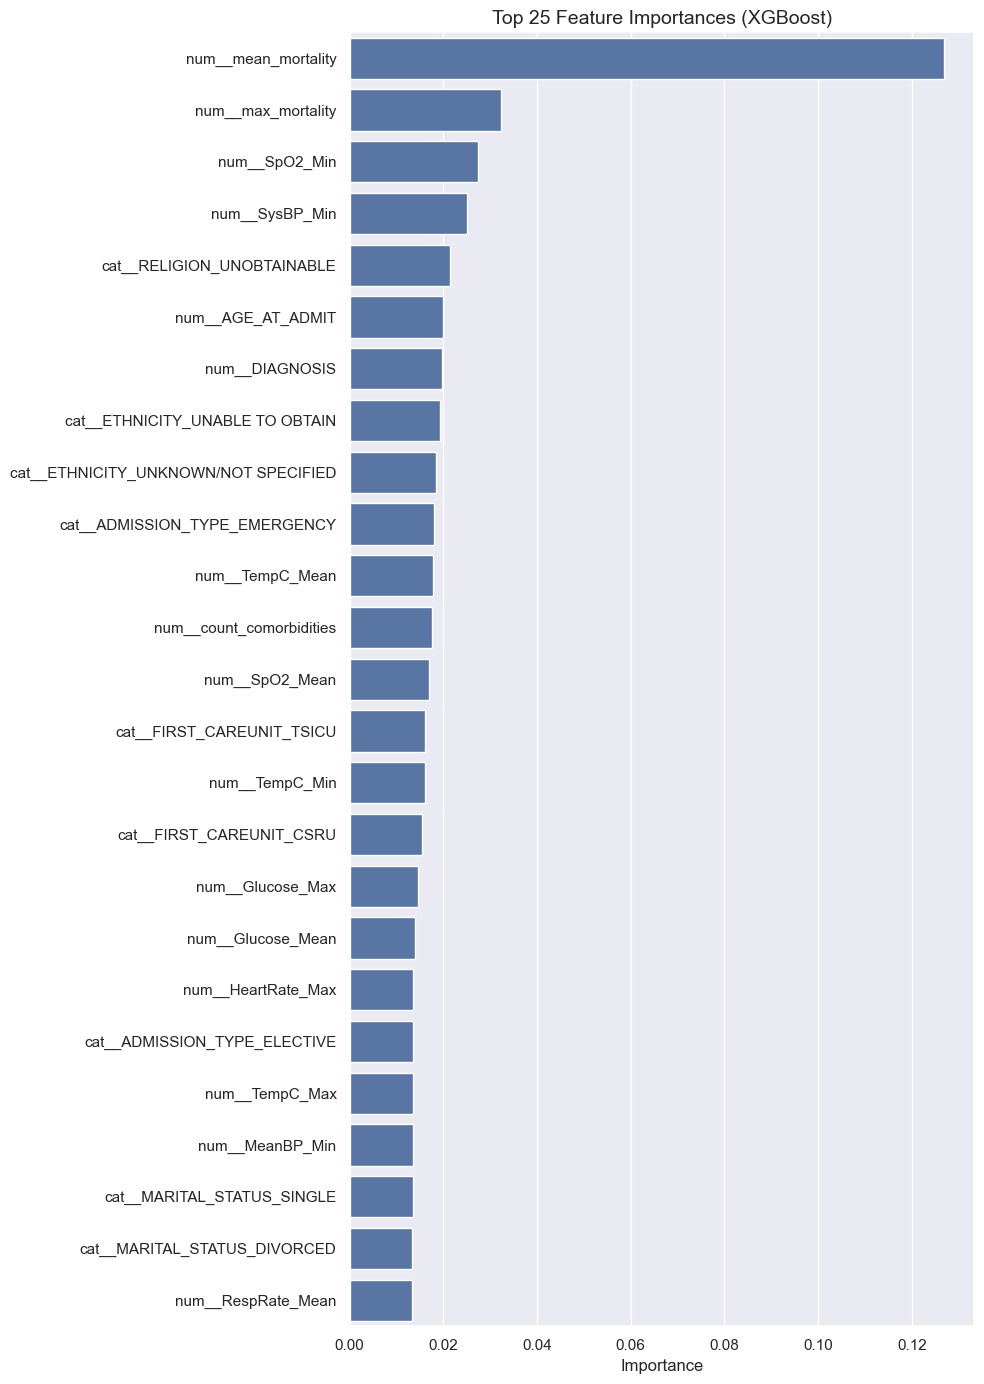

In [15]:
preprocessor = scores["best_model"].named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

# Extract trained classifier
model = scores["best_model"].named_steps["classifier"]
importances = model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 14))
sns.barplot(
    data=fi_df.head(25),
    x="importance",
    y="feature"
)
plt.title("Top 25 Feature Importances (XGBoost)", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## SHAP plots

In [ ]:
import shap
# Split pipeline into components - need to do this in tow steps as the target encoder uses 'DIAGNOSIS" but it is not present in the final dataframe
pipeline = scores["best_model"]
te = pipeline.named_steps["diagnosis_target_encoder"]
pre = pipeline.named_steps["preprocessor"]

# Apply target encoder
X_te = te.transform(train[pipeline_cols])
# Apply column transformer
X_processed = pre.transform(X_te)

# Get feature names
feature_names = pre.get_feature_names_out()
classifier = pipeline.named_steps["classifier"]

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_processed)
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    plot_type="dot",
    max_display=30
)